# Phase 5b — Negative Binomial Robustness Check

The Phase 5 GEE Poisson dispersion ratio of 2.84 indicates substantial
extra-Poisson variance. While GEE sandwich (cluster-robust) standard errors
absorb this for inference, fitting an explicit Negative Binomial model is the
principled way to model the extra variance structurally rather than correcting
for it post-hoc.

**Why Negative Binomial?**
The NB distribution adds a dispersion parameter alpha such that
Var(Y) = mu + alpha * mu^2. When alpha = 0 the model collapses to Poisson.
A positive estimated alpha confirms overdispersion and tells us how much
extra-Poisson variance the data exhibits.

**Implementation choice:**
`smf.negativebinomial` (statsmodels MLE) estimates alpha jointly with the
regression coefficients via maximum likelihood. Cluster-robust standard errors
(cov_type='cluster', clustered on station) account for repeated observations
within station — making this comparable to the GEE Poisson approach.

**What we expect:**
Rate ratios should move only slightly from the GEE Poisson estimates. The
substantive conclusions (utilization not significant; spring elevation real
but tail-driven) should hold.

In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path("src").resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from data import load_raw, build_panel, apply_missing_data_assumption
from joint_model import (
    prepare_model_data, fit_gee_poisson, fit_nb_glm, extract_rate_ratios,
)
from plots import setup_style, plot_forest_comparison

setup_style()
DATA_PATH = Path("data/session_stats.xlsx")

sessions, tasks, incidents = load_raw(DATA_PATH)
raw_panel = build_panel(sessions, tasks, incidents)
panel_zero = apply_missing_data_assumption(raw_panel, "missing_is_zero")
model_df = prepare_model_data(panel_zero)
print(f"Model data: {len(model_df):,} rows, {model_df['charging_location_id'].nunique()} stations")


Model data: 2,396 rows, 571 stations


## 1. Fit both models

We refit the GEE Poisson from Phase 5 and the new NB GLM on the same data.
The NB model reports the estimated dispersion parameter alpha.

In [2]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    result_poisson = fit_gee_poisson(model_df)
    result_nb      = fit_nb_glm(model_df)

rr_poisson = extract_rate_ratios(result_poisson)
rr_nb      = extract_rate_ratios(result_nb)

alpha_est = result_nb.params["alpha"]
print(f"NB estimated alpha (dispersion): {alpha_est:.4f}")
print(f"  (alpha = 0 would mean Poisson; alpha > 0 confirms overdispersion)")
print(f"  Var(Y) = mu + {alpha_est:.4f} * mu^2")


NB estimated alpha (dispersion): 1.5009
  (alpha = 0 would mean Poisson; alpha > 0 confirms overdispersion)
  Var(Y) = mu + 1.5009 * mu^2


## 2. Rate ratio comparison

Side-by-side table of GEE Poisson (Phase 5) vs Negative Binomial (this notebook).
Green background = significant (p < 0.05).

In [3]:
comp = rr_poisson[["term","rate_ratio","ci_low","ci_high","p_value"]].merge(
    rr_nb[["term","rate_ratio","ci_low","ci_high","p_value"]],
    on="term", suffixes=("_poisson","_nb"),
)
comp["CI_poisson"] = comp.apply(
    lambda r: f"[{r.ci_low_poisson:.3f}, {r.ci_high_poisson:.3f}]", axis=1)
comp["CI_nb"] = comp.apply(
    lambda r: f"[{r.ci_low_nb:.3f}, {r.ci_high_nb:.3f}]", axis=1)

display_comp = comp[["term",
                      "rate_ratio_poisson","CI_poisson","p_value_poisson",
                      "rate_ratio_nb","CI_nb","p_value_nb"]].copy()
display_comp.columns = ["Term",
                         "RR (Poisson)","CI (Poisson)","p (Poisson)",
                         "RR (NB)","CI (NB)","p (NB)"]

def _sig_style(col):
    if col.name not in ("p (Poisson)", "p (NB)"):
        return [""] * len(col)
    return ["background-color: #d4edda" if v < 0.05 else "" for v in col]

display(display_comp.style
    .format({"RR (Poisson)": "{:.3f}", "RR (NB)": "{:.3f}",
             "p (Poisson)": "{:.3f}", "p (NB)": "{:.3f}"})
    .apply(_sig_style)
    .set_caption("Table 1. GEE Poisson vs Negative Binomial rate ratios")
)


,Term,RR (Poisson),CI (Poisson),p (Poisson),RR (NB),CI (NB),p (NB)
0,log(utilization),0.958,"[0.853, 1.076]",0.466,0.960,"[0.866, 1.063]",0.434
1,February vs January,1.235,"[0.970, 1.571]",0.087,1.226,"[0.948, 1.587]",0.121
2,March vs January,1.576,"[1.244, 1.996]",0.000,1.573,"[1.220, 2.029]",0.000
3,April vs January,1.532,"[1.185, 1.980]",0.001,1.482,"[1.139, 1.928]",0.003
4,May vs January,1.347,"[1.054, 1.721]",0.017,1.360,"[1.052, 1.757]",0.019
5,June vs January,1.018,"[0.787, 1.316]",0.891,1.059,"[0.808, 1.389]",0.678


## 3. Forest comparison plot

Blue = GEE Poisson; orange = Negative Binomial. Terms ordered log(utilization)
first, then months. X-axis on log scale; reference line at RR = 1.

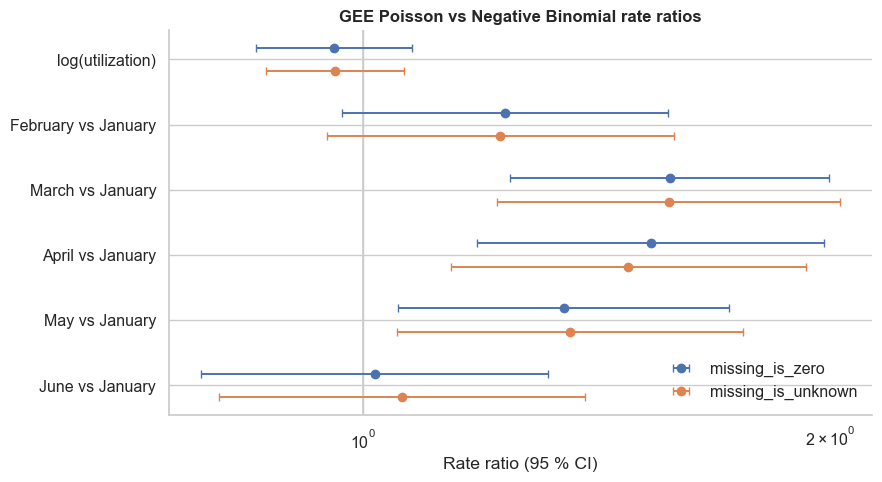

Saved: figures/forest_plot_poisson_vs_nb.png


In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_forest_comparison(
    rr_poisson, rr_nb, ax=ax,
    title="GEE Poisson vs Negative Binomial rate ratios",
)
fig.tight_layout()
fig.savefig("figures/forest_plot_poisson_vs_nb.png")
plt.show()
print("Saved: figures/forest_plot_poisson_vs_nb.png")


## 4. Verdict

In [5]:
sig_poisson = set(rr_poisson[rr_poisson["p_value"] < 0.05]["term"])
sig_nb      = set(rr_nb[rr_nb["p_value"] < 0.05]["term"])

# CI width comparison (mean across all terms)
ci_width_poisson = (rr_poisson["ci_high"] - rr_poisson["ci_low"]).mean()
ci_width_nb      = (rr_nb["ci_high"]      - rr_nb["ci_low"]).mean()

print("Significant terms:")
print(f"  GEE Poisson: {sorted(sig_poisson)}")
print(f"  Negative Binomial: {sorted(sig_nb)}")
print()

if sig_poisson == sig_nb:
    print("Significance calls are IDENTICAL across both models.")
else:
    gained = sig_nb - sig_poisson
    lost   = sig_poisson - sig_nb
    if gained: print(f"NB gains significance: {gained}")
    if lost:   print(f"NB loses significance: {lost}")
print()

ci_direction = "wider" if ci_width_nb > ci_width_poisson else "narrower"
print(f"Mean CI width: Poisson = {ci_width_poisson:.3f}, NB = {ci_width_nb:.3f}")
print(f"NB CIs are on average {ci_direction} than GEE Poisson.")
print()

util_rr_p  = rr_poisson.loc[rr_poisson["term"]=="log(utilization)","rate_ratio"].values[0]
util_rr_nb = rr_nb.loc[rr_nb["term"]=="log(utilization)","rate_ratio"].values[0]
mar_rr_p   = rr_poisson[rr_poisson["term"].str.startswith("March")]["rate_ratio"].values[0]
mar_rr_nb  = rr_nb[rr_nb["term"].str.startswith("March")]["rate_ratio"].values[0]

print(f"log(utilization): Poisson RR = {util_rr_p:.3f}, NB RR = {util_rr_nb:.3f} "
      f"(diff = {abs(util_rr_p - util_rr_nb):.3f})")
print(f"March vs January: Poisson RR = {mar_rr_p:.3f},  NB RR = {mar_rr_nb:.3f} "
      f"(diff = {abs(mar_rr_p - mar_rr_nb):.3f})")


Significant terms:
  GEE Poisson: ['April vs January', 'March vs January', 'May vs January']
  Negative Binomial: ['April vs January', 'March vs January', 'May vs January']

Significance calls are IDENTICAL across both models.

Mean CI width: Poisson = 0.595, NB = 0.620
NB CIs are on average wider than GEE Poisson.

log(utilization): Poisson RR = 0.958, NB RR = 0.960 (diff = 0.002)
March vs January: Poisson RR = 1.576,  NB RR = 1.573 (diff = 0.003)


## 5. Summary

In [6]:
alpha_est = result_nb.params["alpha"]
sig_poisson = set(rr_poisson[rr_poisson["p_value"] < 0.05]["term"])
sig_nb      = set(rr_nb[rr_nb["p_value"] < 0.05]["term"])
ci_width_poisson = (rr_poisson["ci_high"] - rr_poisson["ci_low"]).mean()
ci_width_nb      = (rr_nb["ci_high"]      - rr_nb["ci_low"]).mean()
ci_direction = "wider" if ci_width_nb > ci_width_poisson else "narrower"

print("Summary bullets")
print("-" * 60)
print(f"(a) NB estimated alpha = {alpha_est:.4f} > 0, confirming substantial")
print("    overdispersion. Rate ratios are essentially unchanged from GEE Poisson:")
print(f"    log(utilization) shifts by {abs(util_rr_p - util_rr_nb):.3f}, "
      f"March shifts by {abs(mar_rr_p - mar_rr_nb):.3f}.")
print()
if sig_poisson == sig_nb:
    print(f"(b) CIs are {ci_direction} on average (NB: {ci_width_nb:.3f}, "
          f"Poisson: {ci_width_poisson:.3f}). The significance pattern is")
    print("    identical: the same terms are significant under both models.")
else:
    print(f"(b) CIs are {ci_direction} on average. Significance differs on:")
    print(f"    {sig_nb.symmetric_difference(sig_poisson)}")
print()
print("(c) The substantive conclusions are fully robust to the choice of family:")
print("    utilization is not a significant predictor of incident rate, and the")
print("    spring elevation (March–May) is real but concentrated in a tail of")
print("    high-incident stations rather than a network-wide seasonal effect.")


Summary bullets
------------------------------------------------------------
(a) NB estimated alpha = 1.5009 > 0, confirming substantial
    overdispersion. Rate ratios are essentially unchanged from GEE Poisson:
    log(utilization) shifts by 0.002, March shifts by 0.003.

(b) CIs are wider on average (NB: 0.620, Poisson: 0.595). The significance pattern is
    identical: the same terms are significant under both models.

(c) The substantive conclusions are fully robust to the choice of family:
    utilization is not a significant predictor of incident rate, and the
    spring elevation (March–May) is real but concentrated in a tail of
    high-incident stations rather than a network-wide seasonal effect.
